# NOTE:
# This notebook was originally executed from:
# /content/drive/MyDrive/notebooks/
# Paths may need to be adjusted if executed from a different directory.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Concatenate



Connection to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Getting the dataframe from the drive

In [ ]:
df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df3.csv')
df3

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %,tcc,tclw,sin_h,cos_h,sin_doy,cos_doy
0,2021-07-29 00:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,39.964287,0.153527,0.000000,1.000000,-0.455907,-0.890028
1,2021-07-29 00:15:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,35.300870,0.130069,0.000000,1.000000,-0.455907,-0.890028
2,2021-07-29 00:30:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,30.637451,0.106611,0.000000,1.000000,-0.455907,-0.890028
3,2021-07-29 00:45:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,25.974033,0.083153,0.000000,1.000000,-0.455907,-0.890028
4,2021-07-29 01:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.21,15.70,2.96,94.50,21.310616,0.059695,0.258819,0.965926,-0.455907,-0.890028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125659,2025-05-11 22:45:00,0.0,0.0,0.000331,0.00617,0.000835,0.0,0.0,1.0,0.0,17.28,10.68,0.00,88.15,98.551765,0.000439,-0.500000,0.866025,0.774884,-0.632103
125660,2025-05-11 23:00:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.412260,0.000063,-0.258819,0.965926,0.774884,-0.632103
125661,2025-05-11 23:15:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.502030,0.000048,-0.258819,0.965926,0.774884,-0.632103
125662,2025-05-11 23:30:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.591800,0.000033,-0.258819,0.965926,0.774884,-0.632103


Features of initial df

In [ ]:
df3.shape

(125664, 20)

In [ ]:
df3.dtypes

,0
Time,object
Front POA1 (W/m2),float64
Front POA2 (W/m2),float64
Rear 1 (W/m2),float64
Rear 2 (W/m2),float64
Rear 3 (W/m2),float64
G,float64
W,float64
B,float64
S,float64


In [ ]:
df3['Time']=pd.to_datetime(df3['Time'],format='%Y-%m-%d %H:%M:%S')


Vector of time gaps for window size=96 (1 day)

In [ ]:
time_gaps=[9888, 28416, 67584, 70272, 30144, 85440, 87264,87360, 97728, 105888]

Correlation

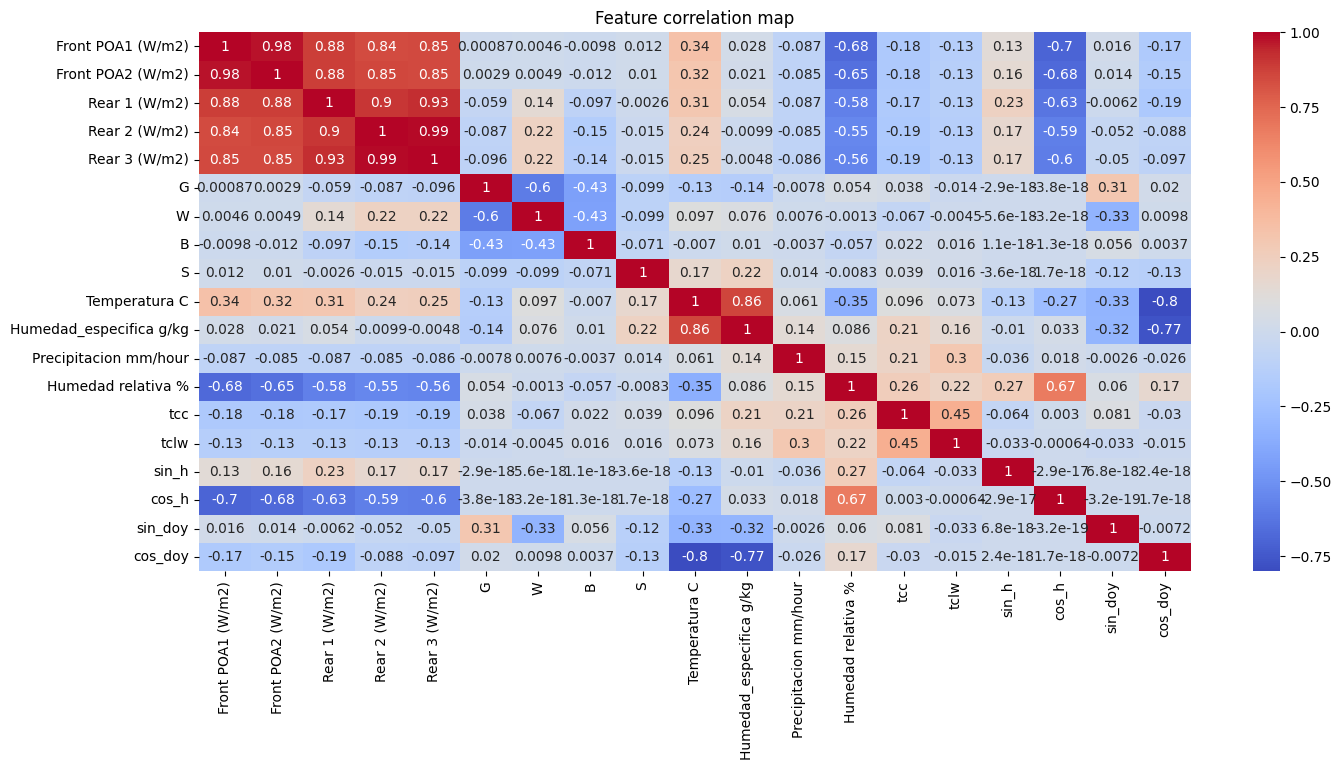

In [ ]:
data_corr=df3.select_dtypes(include=["float64"])
plt.figure(figsize=(16,7))
sns.heatmap(data_corr.corr(),annot=True,cmap="coolwarm")
plt.title("Feature correlation map")
plt.show()

Define seed

In [ ]:
import os
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED']=str(42)

Define parameters

In [ ]:
n_exo_var=5  #[2,3,4,5],
#2=[T,relative_humidity],
#3=[T,relative_humidity,tcc],
#4=[T,relative_humidity, tcc ,precipitation]
#5=[T,relative_humidity, tcc, precipitation, specific humidity]
win_size=96 #[4,8,12,16,20,24,....,96,...192,...]
#It is the window that you want to predict, have in mind that t=15min, so win_size=4 means 1 hour
obs_window=384 #[96,192,288,384,480,576,672,...]
#It is the information of the past that you are using to predict
#obs_window=96,192,288, means 1 day, 2 days and 3 days respectively
gap_setting=0 #[96,192,288]
#it is the space (gap) between the last data and the start of horizon

Define window size for POA1, POA2, Rear 1, Rear 2, Rear3

In [ ]:
def df_to_x_y(window_size,lookback,n_exo,gap_set):
  df_ref=pd.DataFrame({'POA1':np.reshape(df3['Front POA1 (W/m2)'],(df3['Front POA1 (W/m2)'].shape[0]))})
  df_ref['POA2']=df3['Front POA2 (W/m2)']
  df_ref['Rear1']=df3['Rear 1 (W/m2)']
  df_ref['Rear2']=df3['Rear 2 (W/m2)']
  df_ref['Rear3']=df3['Rear 3 (W/m2)']

  df_ref['temp']=df3['Temperatura C']
  df_ref['hum']=df3['Humedad relativa %']

  if n_exo==3:
    df_ref['tcc']=df3['tcc']
  if n_exo==4:
    df_ref['tcc']=df3['tcc']
    df_ref['prep']=df3['Precipitacion mm/hour']
  if n_exo==5:
    df_ref['tcc']=df3['tcc']
    df_ref['prep']=df3['Precipitacion mm/hour']
    df_ref['esp']=df3['Humedad_especifica g/kg']

  df_ref['sin_h']=df3['sin_h']
  df_ref['cos_h']=df3['cos_h']
  df_ref['sin_doy']=df3['sin_doy']
  df_ref['cos_doy']=df3['cos_doy']
  df_ref['G']=df3['G']
  df_ref['W']=df3['W']
  df_ref['B']=df3['B']
  df_ref['S']=df3['S']

  X=[]
  y=[]
  future_albedo=[]
  i=0
  #future data vs past data
  while i<=len(df_ref)-lookback-window_size-gap_set:
    if n_exo==2:
      X_past=df_ref[['POA1','POA2','Rear1','Rear2','Rear3','temp','hum','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    if n_exo==3:
      X_past=df_ref[['POA1','POA2','Rear1','Rear2','Rear3','temp','hum','tcc','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    if n_exo==4:
      X_past=df_ref[['POA1','POA2','Rear1','Rear2','Rear3','temp','hum','tcc','prep','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values
    if n_exo==5:
      X_past=df_ref[['POA1','POA2','Rear1','Rear2','Rear3','temp','hum','tcc','prep','esp','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    X.append(X_past)
    y.append(df_ref[['POA1','POA2','Rear1','Rear2','Rear3']][(i+lookback+gap_set):(lookback+window_size+i+gap_set)])
    future_albedo.append(df_ref[['G','W','B','S']].iloc[(i+lookback+gap_set+48),:])

    if (lookback+window_size+i+gap_set) in time_gaps:
      if (lookback+window_size+i+gap_set)==87264:
        i=i+window_size*(2+int(lookback/window_size))
      else:
        i=i+window_size*(1+int(lookback/window_size))
    else:
      i=i+window_size

  return np.array(X),np.array(y),np.array(future_albedo)

X1_POA_Rear,y1_POA_Rear,surfaces_Rear=df_to_x_y(window_size=win_size,lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting)

print(X1_POA_Rear.shape)
print(y1_POA_Rear.shape)
print(surfaces_Rear.shape)

(1268, 384, 18)
(1268, 96, 5)
(1268, 4)


Define Training, validation and testing

In [ ]:
XR_POA_Rear_train=X1_POA_Rear[:int(X1_POA_Rear.shape[0]*0.8)]
yR_POA_Rear_train=y1_POA_Rear[:int(y1_POA_Rear.shape[0]*0.8)]
surf_Rear_train=surfaces_Rear[:int(surfaces_Rear.shape[0]*0.8)]

XR_POA_Rear_val=X1_POA_Rear[int(X1_POA_Rear.shape[0]*0.8):int(X1_POA_Rear.shape[0]*0.9)]
yR_POA_Rear_val=y1_POA_Rear[int(y1_POA_Rear.shape[0]*0.8):int(y1_POA_Rear.shape[0]*0.9)]
surf_Rear_val=surfaces_Rear[int(surfaces_Rear.shape[0]*0.8):int(surfaces_Rear.shape[0]*0.9)]

XR_POA_Rear_test=X1_POA_Rear[int(X1_POA_Rear.shape[0]*0.9):]
yR_POA_Rear_test=y1_POA_Rear[int(y1_POA_Rear.shape[0]*0.9):]
surf_Rear_test=surfaces_Rear[int(surfaces_Rear.shape[0]*0.9):]

XR_POA_Rear_train.shape,yR_POA_Rear_train.shape,XR_POA_Rear_val.shape,yR_POA_Rear_val.shape,XR_POA_Rear_test.shape,yR_POA_Rear_test.shape


((1014, 384, 18),
 (1014, 96, 5),
 (127, 384, 18),
 (127, 96, 5),
 (127, 384, 18),
 (127, 96, 5))

In [ ]:
surf_Rear_train.shape,surf_Rear_val.shape,surf_Rear_test.shape

((1014, 4), (127, 4), (127, 4))

Implement RobustScaler

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler_POA1=RobustScaler().fit(XR_POA_Rear_train[:,:,0].reshape(-1,1))
scaler_POA2=RobustScaler().fit(XR_POA_Rear_train[:,:,1].reshape(-1,1))
scaler_Rear1=RobustScaler().fit(XR_POA_Rear_train[:,:,2].reshape(-1,1))
scaler_Rear2=RobustScaler().fit(XR_POA_Rear_train[:,:,3].reshape(-1,1))
scaler_Rear3=RobustScaler().fit(XR_POA_Rear_train[:,:,4].reshape(-1,1))

scaler_Temp=RobustScaler().fit(XR_POA_Rear_train[:,:,5].reshape(-1,1))
scaler_Hum=RobustScaler().fit(XR_POA_Rear_train[:,:,6].reshape(-1,1))

if n_exo_var==4:
  scaler_Prep=RobustScaler().fit(XR_POA_Rear_train[:,:,8].reshape(-1,1))

if n_exo_var==5:
  scaler_Prep=RobustScaler().fit(XR_POA_Rear_train[:,:,8].reshape(-1,1))
  scaler_esp=RobustScaler().fit(XR_POA_Rear_train[:,:,9].reshape(-1,1))


In [ ]:

X1_POA_Rear_train=XR_POA_Rear_train
y1_POA_Rear_train=yR_POA_Rear_train


X1_POA_Rear_val=XR_POA_Rear_val
y1_POA_Rear_val=yR_POA_Rear_val


X1_POA_Rear_test=XR_POA_Rear_test

Transform with the scalers created

In [ ]:
X1_POA_Rear_train[:,:,0]=(scaler_POA1.transform(XR_POA_Rear_train[:,:,0].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,0]=(scaler_POA1.transform(yR_POA_Rear_train[:,:,0].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,0]=(scaler_POA1.transform(XR_POA_Rear_val[:,:,0].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,0]=(scaler_POA1.transform(yR_POA_Rear_val[:,:,0].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,0]=(scaler_POA1.transform(XR_POA_Rear_test[:,:,0].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,1]=(scaler_POA2.transform(XR_POA_Rear_train[:,:,1].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,1]=(scaler_POA2.transform(yR_POA_Rear_train[:,:,1].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,1]=(scaler_POA2.transform(XR_POA_Rear_val[:,:,1].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,1]=(scaler_POA2.transform(yR_POA_Rear_val[:,:,1].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,1]=(scaler_POA2.transform(XR_POA_Rear_test[:,:,1].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,2]=(scaler_Rear1.transform(XR_POA_Rear_train[:,:,2].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,2]=(scaler_Rear1.transform(yR_POA_Rear_train[:,:,2].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,2]=(scaler_Rear1.transform(XR_POA_Rear_val[:,:,2].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,2]=(scaler_Rear1.transform(yR_POA_Rear_val[:,:,2].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,2]=(scaler_Rear1.transform(XR_POA_Rear_test[:,:,2].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,3]=(scaler_Rear2.transform(XR_POA_Rear_train[:,:,3].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,3]=(scaler_Rear2.transform(yR_POA_Rear_train[:,:,3].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,3]=(scaler_Rear2.transform(XR_POA_Rear_val[:,:,3].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,3]=(scaler_Rear2.transform(yR_POA_Rear_val[:,:,3].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,3]=(scaler_Rear2.transform(XR_POA_Rear_test[:,:,3].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,4]=(scaler_Rear3.transform(XR_POA_Rear_train[:,:,4].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,4]=(scaler_Rear3.transform(yR_POA_Rear_train[:,:,4].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,4]=(scaler_Rear3.transform(XR_POA_Rear_val[:,:,4].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,4]=(scaler_Rear3.transform(yR_POA_Rear_val[:,:,4].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,4]=(scaler_Rear3.transform(XR_POA_Rear_test[:,:,4].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])




X1_POA_Rear_train[:,:,5]=(scaler_Temp.transform(XR_POA_Rear_train[:,:,5].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
X1_POA_Rear_val[:,:,5]=(scaler_Temp.transform(XR_POA_Rear_val[:,:,5].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,5]=(scaler_Temp.transform(XR_POA_Rear_test[:,:,5].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,6]=(scaler_Hum.transform(XR_POA_Rear_train[:,:,6].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
X1_POA_Rear_val[:,:,6]=(scaler_Hum.transform(XR_POA_Rear_val[:,:,6].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,6]=(scaler_Hum.transform(XR_POA_Rear_test[:,:,6].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

if n_exo_var==3:
  X1_POA_Rear_train[:,:,7]=XR_POA_Rear_train[:,:,7]/100
  X1_POA_Rear_val[:,:,7]=XR_POA_Rear_val[:,:,7]/100
  X1_POA_Rear_test[:,:,7]=XR_POA_Rear_test[:,:,7]/100

if n_exo_var==4:
  X1_POA_Rear_train[:,:,7]=XR_POA_Rear_train[:,:,7]/100
  X1_POA_Rear_val[:,:,7]=XR_POA_Rear_val[:,:,7]/100
  X1_POA_Rear_test[:,:,7]=XR_POA_Rear_test[:,:,7]/100
  X1_POA_Rear_train[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_train[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
  X1_POA_Rear_val[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_val[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
  X1_POA_Rear_test[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_test[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])
if n_exo_var==5:
  X1_POA_Rear_train[:,:,7]=XR_POA_Rear_train[:,:,7]/100
  X1_POA_Rear_val[:,:,7]=XR_POA_Rear_val[:,:,7]/100
  X1_POA_Rear_test[:,:,7]=XR_POA_Rear_test[:,:,7]/100
  X1_POA_Rear_train[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_train[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
  X1_POA_Rear_val[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_val[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
  X1_POA_Rear_test[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_test[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])
  X1_POA_Rear_train[:,:,9]=(scaler_esp.transform(XR_POA_Rear_train[:,:,9].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
  X1_POA_Rear_val[:,:,9]=(scaler_esp.transform(XR_POA_Rear_val[:,:,9].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
  X1_POA_Rear_test[:,:,9]=(scaler_esp.transform(XR_POA_Rear_test[:,:,9].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])


Import keras-tuner

In [ ]:
pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.3 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
from keras_tuner import BayesianOptimization

Define Callbacks

In [ ]:

early_stop1=EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)
check_point_poa1=ModelCheckpoint(filepath="model_checkpoint/best_model_poa1.keras",monitor='mae',save_best_only=True)

Define function to optimize hyperparameters

In [ ]:

def create_tun_integral(hp):

    seq_input = keras.layers.Input(shape=(obs_window, (13+n_exo_var)), name='seq-input')

    x = keras.layers.Bidirectional(keras.layers.LSTM(units=hp.Choice('units1', [32, 64, 96, 128]),
             return_sequences=True, activation='tanh'))(seq_input)
    x = keras.layers.Dropout(hp.Choice('drop1', [0.2, 0.3]))(x)
    x = keras.layers.Bidirectional(keras.layers.LSTM(units=hp.Choice('units2', [32, 64]),
             return_sequences=False))(x)
    x = keras.layers.Dropout(hp.Choice('drop2', [0.2, 0.3]))(x)
    x = keras.layers.Dense(units=hp.Choice('units3', [64, 96, 128]), activation='relu')(x)

    surf_input = keras.layers.Input(shape=(4,), name='surf-input')
    s = keras.layers.Dense(32, activation='relu')(surf_input)

    comb = Concatenate()([x, s])

    comb = keras.layers.Dense(units=hp.Choice('dense_mid', [96, 128, 192]), activation='relu')(comb)

    output = keras.layers.Dense(5 * win_size, activation='linear', name='Irr_output')(comb)

    output = keras.layers.Reshape((win_size, 5))(output)

    model = keras.models.Model(inputs=[seq_input, surf_input], outputs=output)

    # Compilación
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('lr', [1e-3, 5e-4, 1e-4])),
        loss='mae',
        metrics=['mae', 'mse', 'mape']
    )

    return model


Define object tuner

In [ ]:
tuner_POA_Rear=BayesianOptimization(create_tun_integral,objective='val_loss',max_trials=140,num_initial_points=28,alpha=1e-4,beta=2.6,project_name='bilstm2_tunv4_df4')

In [ ]:
tuner_POA_Rear.search([X1_POA_Rear_train,surf_Rear_train],y1_POA_Rear_train,epochs=50,
                      validation_data=([X1_POA_Rear_val,surf_Rear_val],y1_POA_Rear_val),callbacks=[early_stop1])
tuner_POA_Rear.results_summary()

Trial 140 Complete [00h 00m 54s]
val_loss: 0.23616819083690643

Best val_loss So Far: 0.22391007840633392
Total elapsed time: 02h 30m 44s
Results summary
Results in ./bilstm2_tunv4_df4
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 073 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 32
drop2: 0.3
units3: 96
dense_mid: 192
lr: 0.001
Score: 0.22391007840633392

Trial 111 summary
Hyperparameters:
units1: 32
drop1: 0.2
units2: 32
drop2: 0.3
units3: 128
dense_mid: 128
lr: 0.0005
Score: 0.22491420805454254

Trial 022 summary
Hyperparameters:
units1: 32
drop1: 0.2
units2: 32
drop2: 0.3
units3: 128
dense_mid: 128
lr: 0.0005
Score: 0.22529573738574982

Trial 011 summary
Hyperparameters:
units1: 32
drop1: 0.3
units2: 32
drop2: 0.2
units3: 64
dense_mid: 96
lr: 0.001
Score: 0.2256588339805603

Trial 127 summary
Hyperparameters:
units1: 96
drop1: 0.2
units2: 32
drop2: 0.3
units3: 128
dense_mid: 192
lr: 0.001
Score: 0.22589504718780518

Trial 098 summary
Hyperparam

Define the model as the best model performed by keras tuner

In [ ]:
model1_POA_Rear_BiLSTM2=tuner_POA_Rear.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Save and load model

In [ ]:
model1_POA_Rear_BiLSTM2.save('/content/drive/MyDrive/Colab Notebooks/models_BiLSTM_RS/model_BiLSTM2_POA_Rear_n5.keras')

In [ ]:
model1_POA_Rear_BiLSTM2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_BiLSTM_RS/model_BiLSTM2_POA_Rear_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:

pred_POA1_p1=model1_POA_Rear_BiLSTM2.predict([X1_POA_Rear_test,surf_Rear_test])
predict_POA1_p1=np.zeros_like(pred_POA1_p1)
scalers=[scaler_POA1, scaler_POA2, scaler_Rear1, scaler_Rear2, scaler_Rear3]
for p in range(0,5):
  predict_POA1_p1[:,:,p]=(scalers[p].inverse_transform(pred_POA1_p1[:,:,p].reshape(-1,1))).reshape(pred_POA1_p1[:,:,p].shape[0],pred_POA1_p1[:,:,p].shape[1])


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step


MAE

In [ ]:
def list_mae(y_true, y_pred):
  mae_list=[]
  for day in range(y_true.shape[0]):
    mae_list.append(mean_absolute_error(y_true[day,:],y_pred[day,:]))
  return mae_list


POA1

In [ ]:
real_loss_POA1=list_mae(yR_POA_Rear_test[:,:,0],predict_POA1_p1[:,:,0])
print(np.mean(real_loss_POA1))

74.82790069815864


In [ ]:
print(real_loss_POA1)

[34.12040375026936, 67.60413239916454, 108.62400624192965, 69.0379155882455, 31.123288682228083, 38.84879096970878, 43.97434101724574, 33.4259219974055, 21.072978738750354, 98.80112892809107, 67.6853876558964, 24.916171247107098, 133.89921304473356, 67.42884608313763, 99.36272603084943, 51.54786109472875, 92.97441656766273, 64.77077377964734, 101.17516285619207, 83.5311539960823, 69.44207844999671, 20.269940395371126, 93.70913876258517, 72.64821344089678, 94.76844131893058, 84.22958800841769, 44.74599827754099, 179.53962341791205, 58.974436635245915, 74.89735337779457, 58.58152811557947, 26.247841687239955, 22.77494590572117, 80.48962498366784, 104.54260285679385, 28.186193861541057, 62.61769958989546, 123.02217016716965, 33.70757826681528, 44.77649442810124, 78.35964827950717, 53.37943863429982, 27.95422421238527, 61.38900936775851, 88.27640642641977, 104.2855402590222, 103.56860422267512, 59.55360443985803, 43.362912068575575, 100.59441375105483, 75.74295959245082, 49.500101568448976

POA2

In [ ]:
real_loss_POA2=list_mae(yR_POA_Rear_test[:,:,1],predict_POA1_p1[:,:,1])
print(np.mean(real_loss_POA2))


72.11472913480536


In [ ]:
print(real_loss_POA2)

[41.799737218029236, 61.362033299466155, 91.55429807102621, 72.21676143723, 41.586897819678946, 34.24562840992189, 43.28297087453908, 38.70489044960146, 21.16484196548522, 104.86495819511468, 75.30285603957724, 21.257366177625766, 131.9077278727881, 61.60572301442166, 92.13161755240759, 45.985845942253775, 82.65667761376841, 70.55972511881681, 101.8494835796957, 88.29597338705253, 77.32249306560625, 17.044583112725828, 98.88328422716289, 73.88550151859715, 95.71658328356773, 89.02631453097058, 40.27885810001039, 172.5577640939865, 55.12821575402483, 71.58849936646999, 57.84412833632473, 25.261569007602386, 20.108242398966336, 81.98357483021903, 96.7698225335327, 21.398215287553455, 59.45388313185452, 114.20922994566989, 32.12027685411791, 43.949307269049, 82.35731062030392, 48.25245379383057, 24.861802826415172, 58.67272652134394, 85.17384905385663, 98.1999796914328, 97.06920783396362, 55.55602051268307, 49.7839249656256, 100.04506639696574, 78.54397290549934, 51.20996916098431, 85.659

Rear1

In [ ]:
real_loss_Rear1=list_mae(yR_POA_Rear_test[:,:,2],predict_POA1_p1[:,:,2])
print(np.mean(real_loss_Rear1))

8.188291847104436


In [ ]:
print(real_loss_Rear1)

[2.638906811503504, 11.76844194218782, 35.20832167658947, 14.988606935856433, 14.38705473324765, 8.456515060151098, 11.994954039266444, 6.611044893810443, 2.3393656545008334, 8.32254259168539, 6.089167371494863, 2.0392965475421847, 13.594278327623693, 5.615873115056981, 8.375628460738994, 36.67458486365931, 12.77322737159154, 17.64943945233094, 19.938750782478554, 14.336417376069582, 12.669337473574975, 3.440419639565363, 9.075756443887734, 6.591869513831245, 8.044677967130943, 7.917396459292793, 4.599633995631902, 13.645339052791487, 5.619722424239442, 6.199703767068996, 5.542282125295414, 2.6365831523735035, 3.231708977120004, 7.396491292127712, 8.068935390150617, 2.4089276989359907, 4.682553139258858, 9.07529953086217, 8.97114040496832, 3.253149299442729, 7.521052304732803, 5.474957297989088, 3.13796383936522, 5.636553757826231, 6.1794701850961635, 7.200012002755592, 6.6860110850589605, 4.670737740994286, 6.001002808837479, 9.792856529494735, 7.1320381083064275, 5.998408927384261, 8

Rear2

In [ ]:
real_loss_Rear2=list_mae(yR_POA_Rear_test[:,:,3],predict_POA1_p1[:,:,3])
print(np.mean(real_loss_Rear2))

6.548573714692518


In [ ]:
print(real_loss_Rear2)

[1.499915128751666, 7.977879578957153, 27.357900311317707, 9.710593633885603, 9.592359736601155, 5.704812586574659, 10.618216735907183, 2.663629686670556, 2.1281644365422694, 6.769937041279138, 4.180501348956946, 1.7616770297018423, 11.348940078474016, 3.7413219986031954, 6.229137788713139, 27.260026694429488, 4.544080864993204, 10.124190629849702, 13.254654825192768, 9.198881215401412, 7.952810188187532, 2.071370132054103, 5.772216637345539, 5.033566986153912, 6.297050232477197, 6.3492535893933075, 2.3087744955384815, 10.747180422173713, 3.862567418575663, 5.431338397799234, 3.53941133528947, 2.2802830048648164, 1.8061142881425092, 5.992730445723825, 6.901702250660471, 1.9835585725254525, 3.2314699484488187, 9.099485486638917, 4.180268799298123, 2.7582358119431603, 4.3987014795112955, 3.276985915684687, 1.8314427397189972, 5.122858274580077, 8.10328888877878, 8.79368619009063, 8.196562967256867, 3.169776884858005, 2.814530873695968, 7.765490330817104, 4.941767986118152, 4.849933053418

Rear3

In [ ]:
real_loss_Rear3=list_mae(yR_POA_Rear_test[:,:,4],predict_POA1_p1[:,:,4])
print(np.mean(real_loss_Rear3))

8.01184791489112


In [ ]:
print(real_loss_Rear3)

[1.8113412706566947, 9.795797681829724, 27.991866626883933, 8.810274708689748, 7.606725046517053, 5.01720032529913, 10.410174080534018, 3.0184535510711776, 2.464304356914658, 9.11292129465361, 6.25018492152725, 1.9833761930982174, 13.576680803518668, 4.067757803845203, 7.279304863292339, 29.70930036837755, 5.163034783416424, 11.657272765129491, 14.702598551164307, 11.484755963826425, 10.208575975288134, 2.7622110455786975, 8.670088151603286, 6.882961614009464, 8.711539359165617, 8.539945208900109, 3.0291807342353962, 14.226862175249982, 4.9821806543637726, 6.692801354804149, 5.677998519036329, 2.8909916969961436, 2.0910813726453887, 8.039064001287974, 7.6398842780451615, 2.6354107032875613, 4.912185505615397, 9.72911947990469, 5.2724046043002515, 3.5217287073797983, 8.038760939393386, 4.377520404402974, 2.287112244065963, 5.667008299579414, 8.60586916542352, 9.549349085081408, 8.31631036827052, 5.79564620884211, 5.262784691660075, 11.338206485675704, 7.789347230331441, 6.23378222930276

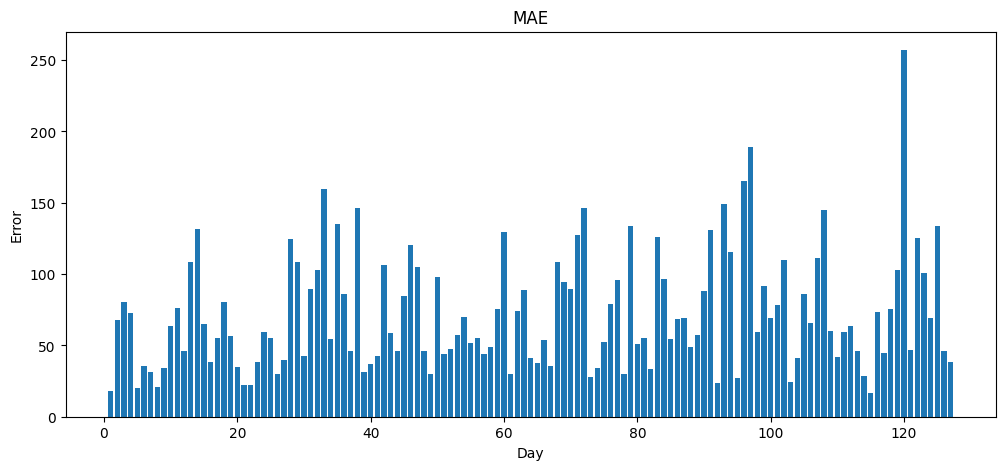

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA1)+1), real_loss_POA1)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
def list_r2(y_true, y_pred):
  r2_list=[]
  for day in range(y_true.shape[0]):
    r2_list.append(r2_score(y_true[day,:],y_pred[day,:]))
  return r2_list

POA1

In [ ]:
real_r2_POA1=list_r2(yR_POA_Rear_test[:,:,0],predict_POA1_p1[:,:,0])
print(np.mean(real_r2_POA1))

-11.084583409415409


In [ ]:
print(real_r2_POA1)

[0.9481976280403377, -1096.0425377049446, 0.09261214283686259, 0.654472341515514, 0.9640492243020135, 0.8912340341538771, 0.5045394994405096, 0.93181188904804, 0.8095193139539545, 0.5922037399818061, 0.7913001601193118, 0.6646046347431727, 0.07783449775591877, -7.359134819612475, -45.54719855212181, 0.8779810707596916, 0.34766925400093907, 0.855556717419109, 0.4423683074402479, 0.6951069407425218, 0.7472660438885647, 0.789321192691434, 0.7076569391450405, 0.5929119358038941, 0.5586044215994463, 0.6430336559126624, -10.159588866041203, -0.12630821965966255, 0.2461475314039714, 0.4011424858777207, 0.8414051904477731, 0.8123145713419078, 0.07526952742523974, 0.5874684564989786, -5.933994175570449, 0.6574254034282166, 0.8831160133152309, -6.9927933505754565, -91.26110422712631, 0.1650497535118447, 0.8255401543705926, -0.5013077077399135, 0.23026005941418726, 0.8580836294999147, 0.4919007279043264, -2.2097409727616233, -0.49152785966448453, 0.8815371239929515, 0.9478649667090884, 0.73280735

POA2

In [ ]:
real_r2_POA2=list_r2(yR_POA_Rear_test[:,:,1],predict_POA1_p1[:,:,1])
print(np.mean(real_r2_POA2))

-58.91836756989913


In [ ]:
print(real_r2_POA2)

[0.9229412154091247, -3664.7665181045277, 0.08948747757895947, 0.6132645465782505, 0.9252421635131803, 0.9249630478081305, 0.46088812957399883, 0.9053207116220708, 0.7740599730948339, 0.5328240230787102, 0.7385771154008801, 0.7002248994775706, 0.05236260900397527, -8.49204017597307, -51.10825282509372, 0.902293681962419, 0.4316835966297966, 0.8148473655121737, 0.3976553494377012, 0.643282740449899, 0.6978647383442048, 0.8005662445453254, 0.6564808648790752, 0.532617162198445, 0.50653110648327, 0.5943707524643481, -11.35977415554108, -0.12777587573907345, 0.3102870227337543, 0.37783623036001435, 0.8304176212212049, 0.7759732146100401, 0.05216124089886476, 0.5454875815787915, -6.096446107699057, 0.738822394713657, 0.857183965854023, -7.195739808823847, -3560.8952610417605, 0.1235780230959832, 0.7985243080094073, -0.41891657728891407, 0.19675184220270148, 0.8566895619420279, 0.4145821681473506, -2.6340294162254434, -0.6001669500203275, 0.8724875496893048, 0.9288792854484591, 0.70476085769

Rear1

In [ ]:
real_r2_Rear1=list_r2(yR_POA_Rear_test[:,:,2],predict_POA1_p1[:,:,2])
print(np.mean(real_r2_Rear1))

-2.7871369478228827


In [ ]:
print(real_r2_Rear1)

[0.954863482889779, 0.2777873676414988, -0.21942528927202498, 0.46413539182128494, 0.6263208630210282, 0.7584160052466911, 0.3063846918218228, 0.8463965301455005, 0.8661615616705098, 0.6027080925738387, 0.783915462886025, 0.834425253397339, 0.009986327725148292, -9.721074309148452, -87.35579500529579, 0.2702584337851711, 0.7077649032236017, 0.45618302674079914, 0.09531339832419339, 0.4212436633284914, 0.44386310336361856, 0.7722438367252328, 0.6584849086450338, 0.5703955979450966, 0.5715857511815485, 0.5929495586489164, -44.470461991837155, -0.01973266653956407, 0.4689666862083195, 0.48571402918783146, 0.833130400170357, 0.7949354716270204, -4.291496555735796, 0.5427984011039, -3.367482253396931, 0.7449031924812817, 0.9024334223859168, -2.950523472648396, 0.13776255263361015, 0.33861945423715567, 0.8021205917476121, -0.2581249581347791, -0.5325269835031241, 0.8491364004828699, 0.6257430767587107, -0.573936164478815, 0.44630788195203874, 0.9144811300444323, 0.8684688580768782, 0.6794953

Rear2

In [ ]:
real_r2_Rear2=list_r2(yR_POA_Rear_test[:,:,3],predict_POA1_p1[:,:,3])
print(np.mean(real_r2_Rear2))

-15.431263739201055


In [ ]:
print(real_r2_Rear2)

[0.9704449548442433, 0.10804567542213495, -0.2910298259081361, 0.5474494137917956, 0.7411959129420275, 0.8300684313310794, 0.13881650419606117, 0.9455097664335766, 0.6272913638507339, 0.45600062261121765, 0.7895615575530266, 0.6239801437780541, -0.17241800934790175, -26.107643932998652, -740.738805356763, 0.37432226496643717, 0.9309364530154174, 0.6100633486412781, 0.01962280306056363, 0.45779644484492965, 0.5203896574307625, 0.6557675348111296, 0.7113830461626125, 0.4599754077633894, 0.45818328426768506, 0.5050805509295995, -288.2804972965164, -0.21500728473219954, 0.2952862679279602, 0.23514279360338441, 0.8400621878108704, 0.5243756545173996, -11.620826752801094, 0.44694088618777406, -9.323412868579435, 0.5561441700481713, 0.9092220781799427, -12.29339263431774, 0.050448442926410264, 0.059391820496736414, 0.8740613127265651, -0.2662051640873253, -0.5470443780639189, 0.7321296639933117, -0.44535310520153715, -5.260402783710535, -0.7804330972627633, 0.9330302823834743, 0.9368775946180

Rear3

In [ ]:
real_r2_Rear3=list_r2(yR_POA_Rear_test[:,:,4],predict_POA1_p1[:,:,4])
print(np.mean(real_r2_Rear3))

-4.918757797767247


In [ ]:
print(real_r2_Rear3)

[0.9684092117805798, 0.18655229193109135, -0.25161231839817777, 0.6369658577064674, 0.8460431304959911, 0.8889492792687519, 0.20801462912797597, 0.9501380323384826, 0.7228777840082664, 0.4272780613406447, 0.725031140095018, 0.7349753110533634, -0.1422024387482861, -8.881078007368764, -186.43781932946945, 0.3680127920563552, 0.9333426881671402, 0.6180242727634192, 0.07380907553668004, 0.44199807045207895, 0.48421283946608284, 0.6933225854213393, 0.6291073473703435, 0.43560667616602733, 0.41213137108504594, 0.46151769141853993, -58.97842621442618, -0.18127298643067014, 0.3621917066054192, 0.2765669681897458, 0.7898814335519222, 0.6272398252338711, -3.434172308455376, 0.41982996013421414, -5.3841870213286205, 0.5423673531729593, 0.874975528204047, -6.912715269834417, 0.07914417276700725, 0.1266705793010806, 0.7740440788766758, -0.14007601576253825, -0.3924491285399232, 0.8237823377735611, 0.3059437375220243, -2.6142664794099364, -0.13349343396220759, 0.8705677123260924, 0.906552925994213,

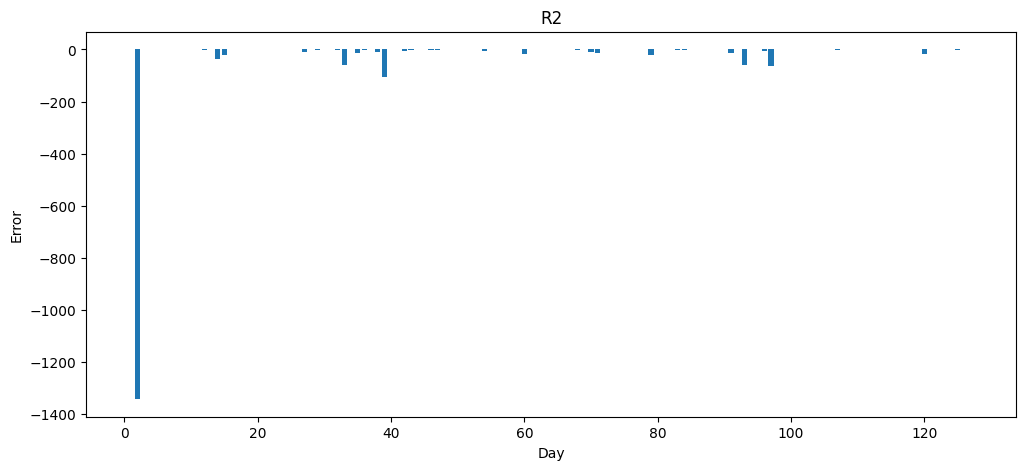

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA1)+1), real_r2_POA1)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
def mape_mod(y_true, y_pred):
  mape_list=[]

  for day in range(y_true.shape[0]):
    y_pred2=[]
    y_true2=[]
    for i in range(0,96):
      if y_true[day,i]>=5 and y_pred[day,i]>=2:
        y_true2.append(y_true[day,i])
        y_pred2.append(y_pred[day,i])
    mape_list.append(np.mean(np.abs((np.array(y_true2) - np.array(y_pred2)) / np.array(y_true2))))
  return mape_list

POA1

In [ ]:
real_mape_poa1=mape_mod(yR_POA_Rear_test[:,:,0],predict_POA1_p1[:,:,0])
print(np.mean(real_mape_poa1))

1.351853845693096


In [ ]:
print(real_mape_poa1)

[np.float64(0.5760606509102186), np.float64(23.78232226872343), np.float64(0.8874536028163231), np.float64(1.146303359327675), np.float64(0.664442292366814), np.float64(0.6448951553718176), np.float64(3.3793722751181656), np.float64(0.6775322230888149), np.float64(0.6507601928094106), np.float64(0.7038523979223273), np.float64(0.5635595560419224), np.float64(0.9065618308506761), np.float64(0.7825279112799238), np.float64(2.521139391389246), np.float64(8.209847707231527), np.float64(1.1113979749168736), np.float64(1.5755673558100174), np.float64(1.0393650356145707), np.float64(0.6787475437852446), np.float64(0.6400486989307855), np.float64(0.5287174582550016), np.float64(0.4689515949699201), np.float64(0.5778694473103496), np.float64(0.5335294030943657), np.float64(0.5563949283595473), np.float64(0.5031237335411409), np.float64(4.572226876077836), np.float64(0.8512889924367593), np.float64(1.8150310411990973), np.float64(0.5100859557340882), np.float64(0.4822281020671171), np.float64(0.

POA2

In [ ]:
real_mape_poa2=mape_mod(yR_POA_Rear_test[:,:,1],predict_POA1_p1[:,:,1])
print(np.mean(real_mape_poa2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_poa2)

[np.float64(0.7488678383784103), np.float64(20.21518998787163), np.float64(1.1009255647502043), np.float64(1.3395921110035593), np.float64(1.0348184232899573), np.float64(0.7118630762607243), np.float64(5.248165353511008), np.float64(1.0171024861870044), np.float64(0.7496790732933526), np.float64(0.8241699205964259), np.float64(0.7343328406102623), np.float64(0.8225084087669506), np.float64(1.0010964067525108), np.float64(2.6374522100464173), np.float64(7.617104466106014), np.float64(1.0176303529314914), np.float64(1.7916894489613888), np.float64(0.7906826431288551), np.float64(0.7680347675046376), np.float64(0.7647829032863569), np.float64(0.5733218460431867), np.float64(0.4341575072578793), np.float64(0.7368805700916764), np.float64(0.7141061824494508), np.float64(0.5964334273679824), np.float64(0.6435614331078329), np.float64(5.339894865393334), np.float64(0.8530361660640324), np.float64(1.50653402905205), np.float64(0.5679533484767066), np.float64(0.7943731539030684), np.float64(0.

Rear1

In [ ]:
real_mape_rear1=mape_mod(yR_POA_Rear_test[:,:,2],predict_POA1_p1[:,:,2])
print(np.mean(real_mape_rear1))

0.7843496266940131


In [ ]:
print(real_mape_rear1)

[np.float64(0.18392185000029324), np.float64(0.6134780599129376), np.float64(0.9041901421197532), np.float64(0.5237134547626554), np.float64(0.5506031509086553), np.float64(0.36369370535171697), np.float64(0.6336621369130722), np.float64(0.3560778584724841), np.float64(0.26680767114579734), np.float64(0.5532670205970476), np.float64(0.40875531167935536), np.float64(0.3242895506804433), np.float64(0.774755473241085), np.float64(2.1728674029691453), np.float64(3.9766783334662805), np.float64(0.6823886237951329), np.float64(0.4299152980814409), np.float64(0.5963623600496581), np.float64(0.7617224688768828), np.float64(0.6338386382093251), np.float64(0.5892005933042941), np.float64(0.40609102556841736), np.float64(0.5300931044676466), np.float64(0.5524277116534583), np.float64(0.5566787342756904), np.float64(0.4876609111113528), np.float64(1.8849731580562652), np.float64(0.8474309010401017), np.float64(0.7321636578744852), np.float64(0.5199318445137806), np.float64(0.4017553211601294), np.

Rear2

In [ ]:
real_mape_rear2=mape_mod(yR_POA_Rear_test[:,:,3],predict_POA1_p1[:,:,3])
print(np.mean(real_mape_rear2))

nan


In [ ]:
print(real_mape_rear2)

[np.float64(0.18161523141064517), np.float64(0.6715684008916526), np.float64(0.9442085188752753), np.float64(0.4232305656914338), np.float64(0.4511132009873231), np.float64(0.31121723389250694), np.float64(0.7369908928224517), np.float64(0.1952473470845507), np.float64(0.42145001337773574), np.float64(0.6439126990101243), np.float64(0.4020120921067615), np.float64(0.3839570767570096), np.float64(0.8600188204167366), np.float64(0.8560243684530587), np.float64(nan), np.float64(0.6452746130417936), np.float64(0.3047386785085821), np.float64(0.49854579838594293), np.float64(0.8452064229422616), np.float64(0.6279384563533579), np.float64(0.6070089299213282), np.float64(0.4222568291783499), np.float64(0.4932939429058308), np.float64(0.5894332085811468), np.float64(0.5853332574014029), np.float64(0.5966774137582131), np.float64(nan), np.float64(0.8834824858356044), np.float64(0.8711996606886471), np.float64(0.6654116558469623), np.float64(0.30888800887951795), np.float64(0.47000250085735873),

Rear3

In [ ]:
real_mape_rear3=mape_mod(yR_POA_Rear_test[:,:,4],predict_POA1_p1[:,:,4])
print(np.mean(real_mape_rear3))

nan


In [ ]:
print(real_mape_rear3)

[np.float64(0.14321406416991914), np.float64(0.6878988068082142), np.float64(0.9367883099845327), np.float64(0.4467722120526004), np.float64(0.36014319259451094), np.float64(0.312015213487545), np.float64(0.66334799241116), np.float64(0.18147530421755093), np.float64(0.3737268226684883), np.float64(0.6609219678501297), np.float64(0.4625972099929809), np.float64(0.3377228806618658), np.float64(0.8500495680647698), np.float64(0.7958606124768498), np.float64(4.0364933271758066), np.float64(0.644114555053031), np.float64(0.255633862467828), np.float64(0.5052424179564612), np.float64(0.8027366325643305), np.float64(0.6446033101794779), np.float64(0.6138460115506308), np.float64(0.4495093356374236), np.float64(0.5537326799516197), np.float64(0.593048896779673), np.float64(0.6408913454375158), np.float64(0.612950092396847), np.float64(nan), np.float64(0.8971812560598561), np.float64(0.8257672365128087), np.float64(0.6633991996379012), np.float64(0.4083794278917324), np.float64(0.4195489283020

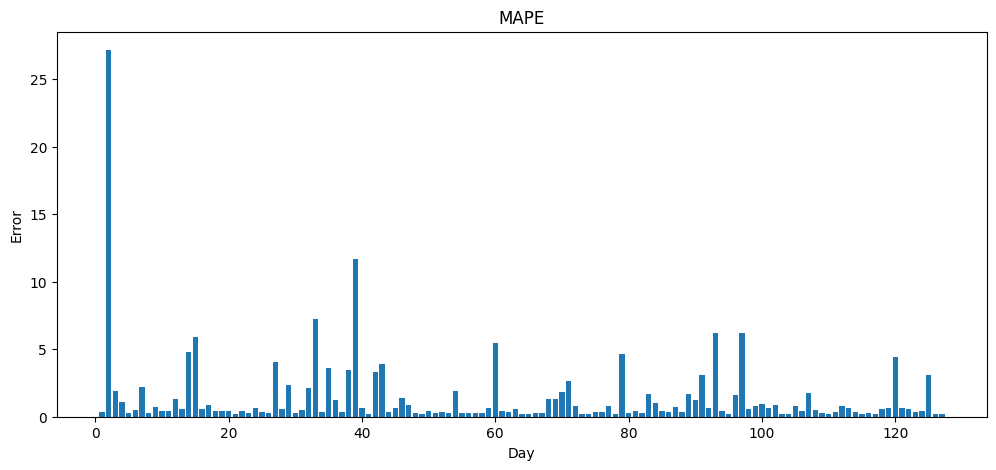

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa1)+1), real_mape_poa1)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

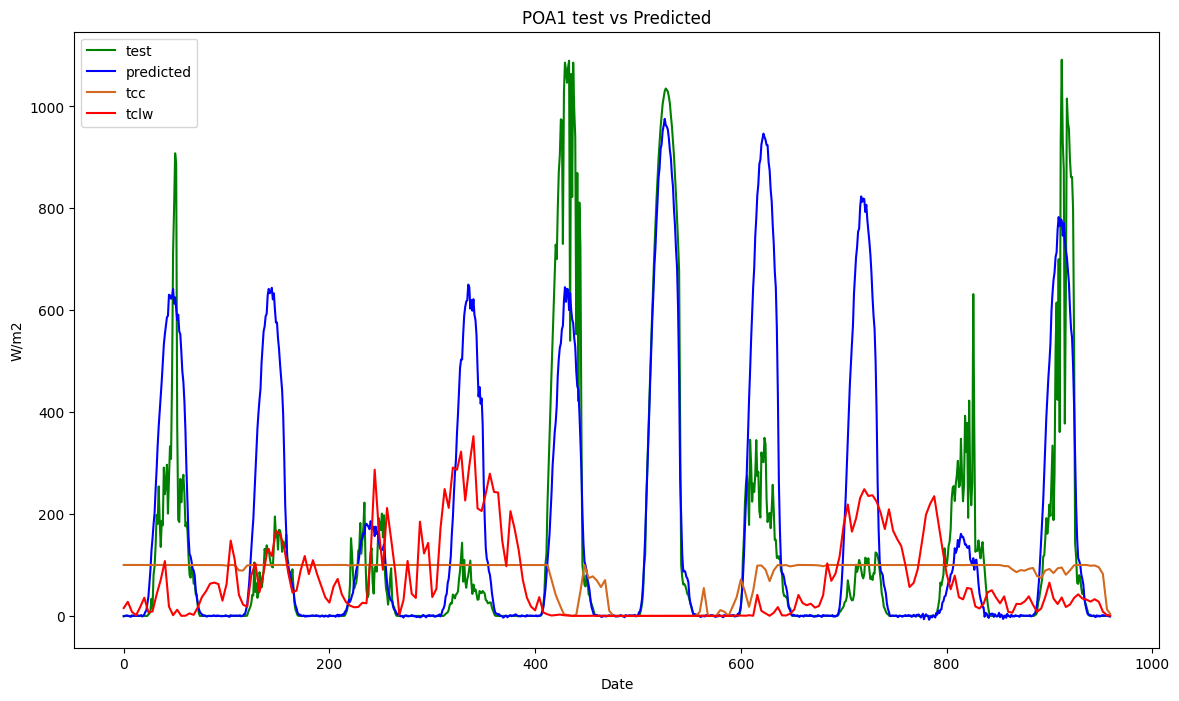

In [ ]:
plt.figure(figsize=(14,8))
st_day=90
end_day=100
dat_clouds=yR_POA_Rear_test.shape[0]*yR_POA_Rear_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA_Rear_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA1_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_POA_Rear_BiLSTM2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 18)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 384, 256)  │    150,528 │ seq-input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     73,984 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      6,240 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 192)       │     24,768 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 480)       │     92,640 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 96, 5)     │          0 │ Irr_output[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 348,320 (1.33 MB)

 Trainable params: 348,320 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In case you need to retrain a model based on the results of keras tuner

In [ ]:
X1_POA_Rear_train=np.concatenate((X1_POA_Rear_train,X1_POA_Rear_val),axis=0)
y1_POA_Rear_train=np.concatenate((y1_POA_Rear_train,y1_POA_Rear_val),axis=0)

surf_Rear_train=np.concatenate((surf_Rear_train,surf_Rear_val),axis=0)

print(X1_POA_Rear_train.shape)
print(y1_POA_Rear_train.shape)
print(surf_Rear_train.shape)

(1141, 384, 18)
(1141, 96, 5)
(1141, 4)


In [ ]:
def create_poa_rear(X,y,epochs,learning_rate1,cb):
    seq_input = keras.layers.Input(shape=(obs_window, (13+n_exo_var)), name='seq-input')

    x = keras.layers.Bidirectional(keras.layers.LSTM(128,return_sequences=True, activation='tanh'))(seq_input)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Bidirectional(keras.layers.LSTM(32,return_sequences=False))(x)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(96, activation='relu')(x)

    surf_input = keras.layers.Input(shape=(4,), name='surf-input')
    s = keras.layers.Dense(32, activation='relu')(surf_input)

    comb = Concatenate()([x, s])
    comb = keras.layers.Dense(192, activation='relu')(comb)

    output = keras.layers.Dense(5 * win_size, activation='linear', name='Irr_output')(comb)
    output = keras.layers.Reshape((win_size, 5))(output)

    model = keras.models.Model(inputs=[seq_input, surf_input], outputs=output)

    # Compilación
    model.compile(
        optimizer=Adam(learning_rate=learning_rate1),
        loss='mae',metrics=['mae', 'mse', 'mape'])


    model.fit(X,y,epochs=epochs,callbacks=[cb])
    return model

In [ ]:
model1_POA_Rear_BiLSTM2_v2=create_poa_rear([X1_POA_Rear_train, surf_Rear_train],y1_POA_Rear_train,100,0.001,check_point_poa1)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.6882 - mae: 0.6882 - mape: 12423246.0000 - mse: 1.9515
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.4004 - mae: 0.4004 - mape: 15875901.0000 - mse: 0.6501
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.3743 - mae: 0.3743 - mape: 11683844.0000 - mse: 0.6139
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.3522 - mae: 0.3522 - mape: 10020252.0000 - mse: 0.5495
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.3354 - mae: 0.3354 - mape: 8780724.0000 - mse: 0.5072
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.3267 - mae: 0.3267 - mape: 8343685.0000 - mse: 0.4818
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.3201 - mae: 0.3201 - mape: 7909611.5000 - mse: 0.4811
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.3109 - mae: 0.3109 - mape: 7664420.0000 - mse: 0.4554
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.3109 -

In [ ]:
model1_POA_Rear_BiLSTM2_v2=load_model("model_checkpoint/best_model_poa1.keras")

Save the model

In [ ]:
model1_POA_Rear_BiLSTM2_v2.save('/content/drive/MyDrive/Colab Notebooks/models_BiLSTM_RS/model_BiLSTM2_POA_Rear_n5_v2.keras')

Load model

In [ ]:
model1_POA_Rear_BiLSTM2_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_BiLSTM_RS/model_BiLSTM2_POA_Rear_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_POA1_p1_v2=model1_POA_Rear_BiLSTM2_v2.predict([X1_POA_Rear_test,surf_Rear_test])
predict_POA1_p1_v2=np.zeros_like(pred_POA1_p1_v2)
scalers=[scaler_POA1, scaler_POA2, scaler_Rear1, scaler_Rear2, scaler_Rear3]
for p in range(0,5):
  predict_POA1_p1_v2[:,:,p]=(scalers[p].inverse_transform(pred_POA1_p1_v2[:,:,p].reshape(-1,1))).reshape(pred_POA1_p1_v2[:,:,p].shape[0],pred_POA1_p1_v2[:,:,p].shape[1])


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step


POA1

In [ ]:
real_loss_POA1_v2=list_mae(yR_POA_Rear_test[:,:,0],predict_POA1_p1_v2[:,:,0])
print(np.mean(real_loss_POA1_v2))

76.05307562407388


In [ ]:
print(real_loss_POA1_v2)

[68.9298407632564, 33.89909997433791, 89.20993128069676, 69.46263054048102, 39.93401827140578, 29.82223471204235, 38.92333581288823, 68.34476686309013, 18.372099456715773, 97.08489832741652, 68.34114797658525, 36.43282220361103, 129.26210539782463, 98.37745536920734, 16.130088270120364, 35.68504285413342, 49.18062602649773, 90.84953517225243, 84.44491773912328, 38.841373813642974, 31.06739111448511, 15.749061125866978, 121.45540995759927, 60.298481453997645, 95.48386517280623, 23.19289041104366, 28.468916990307587, 136.29627159785036, 95.62591215155892, 82.43616962314556, 95.3197285168307, 34.43675340225482, 96.07562221768914, 117.59129519486982, 119.1698504306918, 27.330214044572106, 49.98030959581113, 122.46373235127602, 32.636201009445045, 44.904059436345044, 161.42400394512268, 103.96973663840238, 60.68513020751544, 61.026560023027294, 71.43517223845775, 93.47789018596075, 88.79397109881923, 176.63541201341855, 41.95200141396023, 177.22216780915323, 51.902394955949795, 78.972521885

POA2

In [ ]:
real_loss_POA2_v2=list_mae(yR_POA_Rear_test[:,:,1],predict_POA1_p1_v2[:,:,1])
print(np.mean(real_loss_POA2_v2))

73.38303851168065


In [ ]:
print(real_loss_POA2_v2)

[71.69056854841185, 32.771358175159385, 82.15099911117777, 73.34901178158891, 42.76620187971489, 27.671579402488163, 35.01486878482981, 70.01596843104217, 18.965985503540224, 96.99482719388254, 69.4098176713262, 36.91677642796164, 125.36977652431976, 98.49403583620898, 16.26871376119564, 28.254748987152812, 49.08642203181896, 89.90413799474469, 82.61785998938052, 39.34573594295241, 32.35200605237169, 12.209298172743791, 119.02233016437764, 63.451369179672156, 91.74171705695589, 21.217581299503298, 28.290104494890585, 130.22150172799226, 95.38273543969933, 76.60981750220303, 91.63034071510897, 30.810761920516274, 94.28668239461524, 114.52136386409784, 117.83454221671695, 21.654528750020074, 41.458576400060934, 120.63060038065213, 32.810960967158245, 46.04573138959811, 154.99196517141317, 102.07269474453938, 57.658218082083, 55.07767046591945, 70.155109793868, 96.18825528766376, 89.91608803599358, 163.00581081178495, 43.43698743422865, 169.27359322549788, 50.708534304873005, 75.474038011

Rear1

In [ ]:
real_loss_Rear1_v2=list_mae(yR_POA_Rear_test[:,:,2],predict_POA1_p1_v2[:,:,2])
print(np.mean(real_loss_Rear1_v2))

8.295840244488357


In [ ]:
print(real_loss_Rear1_v2)

[3.980275925773777, 13.886850552742194, 31.426347328271373, 13.393882480722297, 15.797070692946692, 7.41211571560262, 15.43652561291802, 11.31748859408446, 1.708836556730052, 7.644894070826592, 4.2199991693957095, 2.5109013548321077, 13.212830100970779, 8.028993590341402, 1.859763739966329, 38.06994549147018, 15.314511850530701, 20.74588385068246, 18.39440954110053, 10.497612063833445, 9.547196123273006, 3.820614875907696, 10.6449377190925, 4.829437612807537, 7.683899526132664, 2.521857316819696, 2.9882416218824894, 9.758647751825466, 6.492966365641091, 6.499216963869272, 7.820843920559895, 3.574572816159223, 9.21312885111905, 9.968485766893158, 8.379466082523123, 3.182587776416899, 3.376657791949382, 8.565411184988971, 8.430784243635921, 3.589567776699955, 13.184868719039486, 7.7723752764600365, 6.981131351337091, 5.367127618974113, 4.318659742117064, 5.7876632753316315, 6.103295080399497, 14.75503144365259, 6.051017432635942, 15.559312286964612, 5.640103229091095, 7.900783018485652, 

Rear2

In [ ]:
real_loss_Rear2_v2=list_mae(yR_POA_Rear_test[:,:,3],predict_POA1_p1_v2[:,:,3])
print(np.mean(real_loss_Rear2_v2))

6.701696215794697


In [ ]:
print(real_loss_Rear2_v2)

[3.5460096919713546, 8.774412876877316, 24.52731979616731, 10.479419772170234, 14.25324546627165, 7.625730018243533, 12.566473651601152, 9.324291686173007, 1.3683924258777111, 6.234135127328304, 3.193898093218666, 1.8640688885525798, 10.77891831914348, 5.601670165014923, 1.023895319630059, 31.928451825139437, 6.539907212386208, 14.227835869864338, 11.609999673765223, 6.32102814590579, 5.991889179188276, 1.8187641148843892, 8.017937297778417, 3.715155997737187, 6.021687286157736, 1.9908629850376893, 1.7944830338477178, 7.705529240296173, 5.0031930149544825, 5.1155026767577185, 6.251717467044531, 2.572829219336924, 6.595605002932634, 7.734994805651624, 6.421417259435177, 2.3880966372225383, 2.973473027860301, 6.770070245081361, 3.276861049635625, 2.2794861574456524, 10.642328810085774, 5.805170563006858, 5.514470076619118, 4.24961430569277, 3.6687083005279124, 4.606767501233912, 4.912221758466239, 12.348756857846498, 5.29339261941022, 12.895561100888052, 4.96051840672837, 5.9632766003229

Rear3

In [ ]:
real_loss_Rear3_v2=list_mae(yR_POA_Rear_test[:,:,4],predict_POA1_p1_v2[:,:,4])
print(np.mean(real_loss_Rear3_v2))

8.07594582196829


In [ ]:
print(real_loss_Rear3_v2)

[4.091329965622618, 10.859116785647865, 24.403023191094544, 8.187365713519233, 11.146335117561884, 4.795208446685636, 12.715510341892214, 9.299271366861774, 1.494312582738553, 7.990425692971269, 4.2186590358665645, 2.2550911048078244, 12.893425860871275, 6.765819339052208, 1.3761942854708427, 33.42886365399334, 6.031876805481043, 15.459130221279255, 12.602798486972333, 7.340497801151881, 7.149029509568791, 2.471299822602226, 10.395949633066385, 4.914873165456102, 7.865376924202434, 2.8356904619325527, 2.417266432034769, 10.587991952300596, 6.228159655115083, 6.26281717559772, 8.00151080079067, 3.5321016569757355, 8.094754744041097, 9.906449674876116, 7.731859552730142, 2.5652811475652313, 4.548669894772308, 8.015738165100798, 4.242959182526385, 3.329508451448943, 14.170362136378989, 7.131259769348148, 6.383767142900404, 6.395768602208744, 5.058371117455103, 5.531680087237338, 6.119572893604321, 16.081463436564963, 6.736045831530973, 16.56235741400503, 6.645647165476352, 7.2252543095961

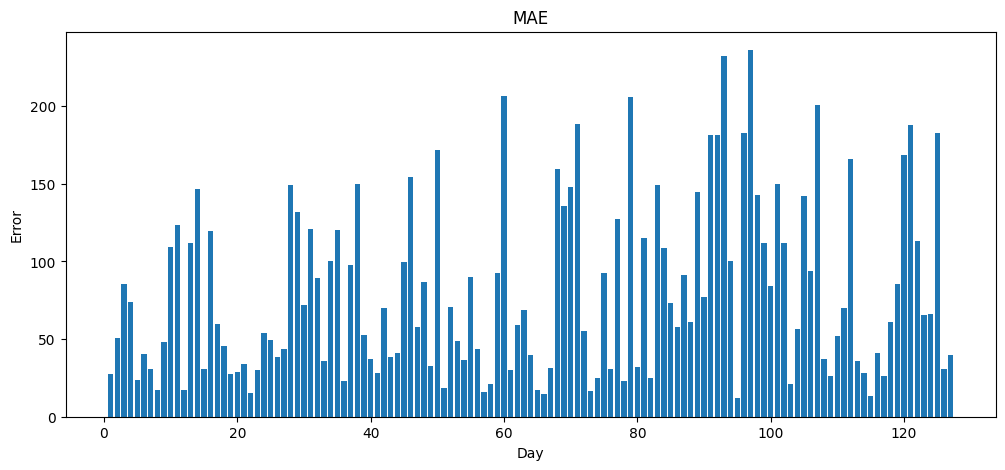

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA1_v2)+1), real_loss_POA1_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

POA1

In [ ]:
real_r2_POA1_v2=list_r2(yR_POA_Rear_test[:,:,0],predict_POA1_p1_v2[:,:,0])
print(np.mean(real_r2_POA1_v2))

-4.934607659747486


In [ ]:
print(real_r2_POA1_v2)

[0.7200622922360915, -326.6535291824506, 0.49587302881325657, 0.5520788902671446, 0.9247717197399014, 0.9225749111880116, 0.38604236292038574, 0.752736325144528, 0.7627185162373691, 0.5965854266548665, 0.7891801491800765, 0.03565232233727378, 0.09851525136354866, -19.893409537650598, -0.5301100291897816, 0.9420618454808908, 0.7809702738757129, 0.6157157802229846, 0.6029351981308448, 0.9290700167000986, 0.9513639153752632, 0.8038759745797972, 0.49782864649149583, 0.648518272682891, 0.5586085648972635, 0.9715830498913703, -4.952583082250575, 0.3248766105938137, -1.5090641758609822, 0.30432035917783296, 0.5582339949647199, 0.5168523672456073, -22.395908670013174, 0.18354074339915116, -9.775342116113181, 0.7164645632157025, 0.9106138190410636, -8.206376630712953, -118.37757006403272, 0.155259303356015, 0.2545257685681436, -5.400043669649723, -3.1378157760265495, 0.8612752531970049, 0.6303756140989474, -1.8344349557260506, -0.21802310872967556, -0.028136461048798855, 0.9505962772025924, 0.1

POA2

In [ ]:
real_r2_POA2_v2=list_r2(yR_POA_Rear_test[:,:,1],predict_POA1_p1_v2[:,:,1])
print(np.mean(real_r2_POA2_v2))

-50.37831473219624


In [ ]:
print(real_r2_POA2_v2)

[0.6927792926279261, -1200.3072003306945, 0.43393977957992846, 0.494240212009569, 0.909190500061675, 0.9274814977364069, 0.3847769371196672, 0.7360077388907597, 0.716196129154016, 0.5831181142285242, 0.7675171421117521, -0.15292036428576972, 0.09681932152893025, -26.376816670521777, -0.9312199038889932, 0.9524864486893325, 0.7564269328743727, 0.6020097537667521, 0.5991629147577523, 0.9235214132440551, 0.9475771373771049, 0.8820790532427859, 0.4941588301115649, 0.6119285204422034, 0.5576553755936873, 0.9742210743750915, -6.584671383117673, 0.3266086009408451, -1.7220831321062402, 0.31125786079603446, 0.5502018091150804, 0.5441444766020207, -27.302971532504753, 0.1731375172963867, -11.512998076987909, 0.7642640884656866, 0.916543862093449, -9.781886283960013, -4965.328703256184, 0.13377331850955776, 0.2599587325225715, -6.045586560644742, -3.895216376029973, 0.8721317961760346, 0.5613593044666457, -2.673804887163499, -0.4703148306833833, -0.00505484286760538, 0.9478877546387645, 0.156908

Rear1

In [ ]:
real_r2_Rear1_v2=list_r2(yR_POA_Rear_test[:,:,2],predict_POA1_p1_v2[:,:,2])
print(np.mean(real_r2_Rear1_v2))

-2.5399810184135556


In [ ]:
print(real_r2_Rear1_v2)

[0.8505693086794213, 0.015590622948235877, 0.009902083325876387, 0.5042935447501271, 0.500074047401715, 0.7864098396233251, -0.07232793328299247, 0.4884840557513399, 0.8881525714100695, 0.6328686882863015, 0.8870770930385499, 0.618293040842133, -0.004561555839674769, -22.284274348287013, -4.030088039680519, 0.203605959478231, 0.5646605548795661, 0.23912974371390794, 0.21936393966654966, 0.6681781766861894, 0.6697036437739776, 0.6492441427701504, 0.4778754657801757, 0.737241047520658, 0.5910215317995542, 0.9574075050503015, -23.13808474017245, 0.430479456053919, -0.03932644524223061, 0.36403389989223445, 0.59711507203045, 0.46674397564922854, -59.04046687811825, 0.20872214009964918, -4.2661894279110815, 0.5730060819752482, 0.939353044686054, -2.883599227702866, 0.15585274315178632, 0.052647451294205894, 0.2921082519993973, -2.3470008099064317, -9.324295213739623, 0.8448080797415574, 0.807912760562048, -0.06551139891030089, 0.5214849799811937, -0.058147175810278506, 0.8612381864239033, 0

Rear2

In [ ]:
real_r2_Rear2_v2=list_r2(yR_POA_Rear_test[:,:,3],predict_POA1_p1_v2[:,:,3])
print(np.mean(real_r2_Rear2_v2))

-11.60831291038559


In [ ]:
print(real_r2_Rear2_v2)

[0.7608208888719934, -0.014933356417347055, -0.05922240659442646, 0.4516715038687872, 0.3787246025642197, 0.686968616160502, -0.16767417386978622, 0.36977636382391543, 0.8064888828592857, 0.5246166644724907, 0.8714222199817827, 0.4740290443830547, -0.15783638452967508, -64.88263051635553, -20.882008536563173, 0.12543100020773967, 0.7689616866762019, 0.2102954106247772, 0.22239663225175588, 0.7333203094978783, 0.7151989081372574, 0.6931725308200842, 0.38724673647471486, 0.6958397599891271, 0.49685964256115567, 0.9550610335668694, -252.84353847813782, 0.3233005098027468, -0.4690944711726115, 0.23034855872778637, 0.49875569104388684, 0.3073642747062133, -260.79666135660784, 0.040316448241003444, -8.426785201845268, 0.35053964309356667, 0.9027279161634413, -6.278335380775083, 0.12346476003126106, 0.09953154178296109, 0.13941617064410305, -3.8435313832470523, -20.718114330888998, 0.8307085191668803, 0.7280943614203379, -0.8374541954388843, 0.3439858644020457, -0.1990824139095675, 0.81059595

Rear3

In [ ]:
real_r2_Rear3_v2=list_r2(yR_POA_Rear_test[:,:,4],predict_POA1_p1_v2[:,:,4])
print(np.mean(real_r2_Rear3_v2))

-4.612357553041214


In [ ]:
print(real_r2_Rear3_v2)

[0.7952407848501949, 0.008494654475796226, 0.026682941949176975, 0.6093801140069504, 0.5785449853300924, 0.865152223560033, -0.10943814415149422, 0.4941567708551705, 0.8639345204323782, 0.5350480467837007, 0.8604228070035584, 0.548989251776387, -0.09937374619743666, -28.812634950124373, -6.262245157312779, 0.18139548967179064, 0.827951113091179, 0.28535894300833986, 0.2996696647804279, 0.7638496107223831, 0.7359834424933829, 0.6876553796741329, 0.4048543905944674, 0.6918517622856115, 0.4925485188647689, 0.943565210617945, -48.78861580562636, 0.2956412221000654, -0.4731869249962546, 0.2637522606780309, 0.5183810306099521, 0.3167510061486254, -99.24381217167215, 0.09380390065857414, -6.380652838767315, 0.6130445768678824, 0.8665683975975099, -4.811801384592556, 0.22421213081995273, 0.04289772830073724, 0.15872649731306665, -3.5112174412429926, -13.867224354231322, 0.8123639976012609, 0.7203017675030612, -0.49860281406495255, 0.350145688149368, -0.16092986288145195, 0.8190610647124665, 0.

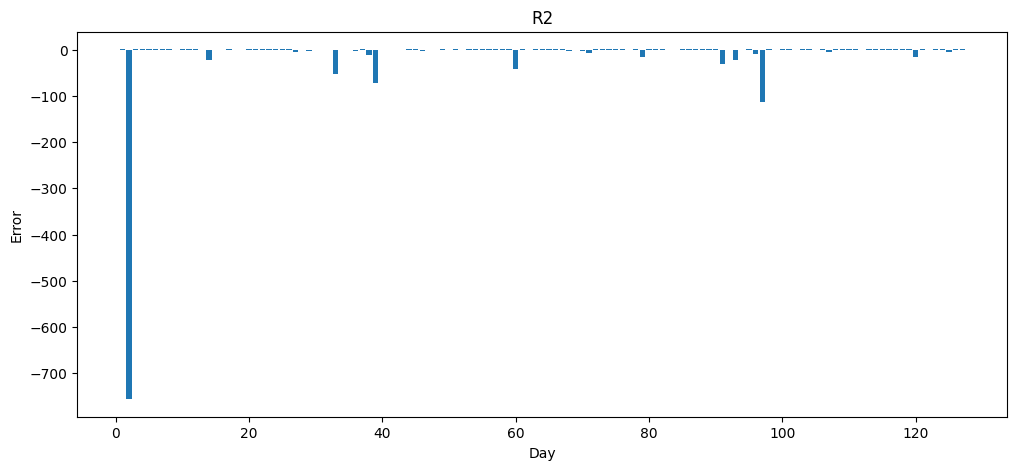

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA1_v2)+1), real_r2_POA1_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Mape

POA1

In [ ]:
real_mape_poa1_v2=mape_mod(yR_POA_Rear_test[:,:,0],predict_POA1_p1_v2[:,:,0])
print(np.mean(real_mape_poa1_v2))

1.1553333801707135


In [ ]:
print(real_mape_poa1_v2)

[np.float64(0.476676493029252), np.float64(13.113211275955724), np.float64(1.3873347333834065), np.float64(0.9523085490726299), np.float64(0.3020513655679915), np.float64(0.38285426179324167), np.float64(1.1165774772019539), np.float64(0.4671474554195138), np.float64(0.4417408760185651), np.float64(0.5361990526334389), np.float64(0.43282620544959544), np.float64(0.9332688310226912), np.float64(0.7119890908094691), np.float64(3.731510204135479), np.float64(1.510983820658742), np.float64(0.5119927242744081), np.float64(0.6456186727297564), np.float64(0.5342240990232655), np.float64(0.5297788133146891), np.float64(0.41157668322232693), np.float64(0.2724703866049152), np.float64(0.3353420076871478), np.float64(0.6174734314317079), np.float64(0.6742830649831971), np.float64(0.5578878899411492), np.float64(0.2599031164122058), np.float64(2.812271501386981), np.float64(0.6192996064192827), np.float64(2.0447514656210113), np.float64(0.6440396281607828), np.float64(0.5437887895482069), np.float

POA2

In [ ]:
real_mape_poa2_v2=mape_mod(yR_POA_Rear_test[:,:,1],predict_POA1_p1_v2[:,:,1])
print(np.mean(real_mape_poa2_v2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_poa2_v2)

[np.float64(0.49614343968554725), np.float64(13.952196778745368), np.float64(2.243452955356979), np.float64(0.9981321391328746), np.float64(0.30407054110709886), np.float64(0.3740393804055744), np.float64(1.6401581369939064), np.float64(0.47983032378660173), np.float64(0.49767304355447856), np.float64(0.5313213399929702), np.float64(0.42065828373430053), np.float64(1.0757831244045624), np.float64(0.6953220041312714), np.float64(4.262586852578593), np.float64(1.5368952022557292), np.float64(0.1863746885650468), np.float64(0.5876683199200998), np.float64(0.46380697234342094), np.float64(0.5327850003966851), np.float64(0.3742887246381605), np.float64(0.29913850587854707), np.float64(0.338141719912671), np.float64(0.5896648932731426), np.float64(0.7553382531191658), np.float64(0.5444953609307714), np.float64(0.24378519819905156), np.float64(3.7195576150260954), np.float64(0.5881107881431484), np.float64(2.0708280227934477), np.float64(0.628009085205352), np.float64(0.4946381408064481), np.

Rear1

In [ ]:
real_mape_rear1_v2=mape_mod(yR_POA_Rear_test[:,:,2],predict_POA1_p1_v2[:,:,2])
print(np.mean(real_mape_rear1_v2))

0.8482803403490642


In [ ]:
print(real_mape_rear1_v2)

[np.float64(0.3188934073995497), np.float64(0.7910904897064918), np.float64(0.842749243911823), np.float64(0.4496878682928369), np.float64(0.6166087817160643), np.float64(0.3443213100866877), np.float64(0.8645047605361581), np.float64(0.6034870654600818), np.float64(0.2734188296981635), np.float64(0.5496475671692311), np.float64(0.3264797395605381), np.float64(0.509961743884461), np.float64(0.8144142162748762), np.float64(3.409575156740917), np.float64(0.5673639309997287), np.float64(0.7587996181418811), np.float64(0.5286949595606141), np.float64(0.741431906351419), np.float64(0.7438928966902014), np.float64(0.4542817036102036), np.float64(0.4639738361569935), np.float64(0.48856967852014144), np.float64(0.634950680872848), np.float64(0.6072048705974507), np.float64(0.5678650090400669), np.float64(0.18460109569787111), np.float64(1.3170105153675373), np.float64(0.6536137817590796), np.float64(1.0145599289153695), np.float64(0.6028562023553738), np.float64(0.5418220913212137), np.float64

Rear2

In [ ]:
real_mape_rear2_v2=mape_mod(yR_POA_Rear_test[:,:,3],predict_POA1_p1_v2[:,:,3])
print(np.mean(real_mape_rear2_v2))

nan


In [ ]:
print(real_mape_rear2_v2)

[np.float64(0.3868116798049841), np.float64(0.8230767141115272), np.float64(0.8830543526393881), np.float64(0.47534377530496297), np.float64(0.6863078855722886), np.float64(0.4739381311743546), np.float64(0.9028615037952973), np.float64(0.6816190102827587), np.float64(0.35126872915971424), np.float64(0.6098901522740209), np.float64(0.34648805763644863), np.float64(0.5654066990506357), np.float64(0.8510387499904691), np.float64(1.6817272048783456), np.float64(nan), np.float64(0.7858957088274312), np.float64(0.33741880850496975), np.float64(0.7666455873315835), np.float64(0.756576272011767), np.float64(0.42485636598966625), np.float64(0.47501966517157207), np.float64(0.4511687647556373), np.float64(0.6709145100995519), np.float64(0.797324651899809), np.float64(0.5826419578712868), np.float64(0.20562266367084256), np.float64(nan), np.float64(0.7168209856801375), np.float64(1.2560300301623626), np.float64(0.6755844895814349), np.float64(0.5738518901627011), np.float64(0.620014973616639), n

Rear3

In [ ]:
real_mape_rear3_v2=mape_mod(yR_POA_Rear_test[:,:,4],predict_POA1_p1_v2[:,:,4])
print(np.mean(real_mape_rear3_v2))

nan


In [ ]:
print(real_mape_rear3_v2)

[np.float64(0.3687674980920473), np.float64(0.806609329543775), np.float64(0.8478420435128138), np.float64(0.41929604133128867), np.float64(0.5716690308169874), np.float64(0.30568167151284775), np.float64(0.8715645542754795), np.float64(0.6119259383967856), np.float64(0.3077012847847564), np.float64(0.5969957425414781), np.float64(0.3388607813838635), np.float64(0.49721581207972737), np.float64(0.8521541392318123), np.float64(1.735086626793364), np.float64(0.1204146856828143), np.float64(0.7447711900726135), np.float64(0.29343688602235146), np.float64(0.7267350605264199), np.float64(0.7189725115757085), np.float64(0.4187872832315971), np.float64(0.45600970055839324), np.float64(0.4601883836503826), np.float64(0.6789033458298247), np.float64(0.680592672370049), np.float64(0.6092496771613852), np.float64(0.22628507751376425), np.float64(nan), np.float64(0.7166468372915691), np.float64(1.2365030709453517), np.float64(0.642039508727378), np.float64(0.5794931278711937), np.float64(0.6134110

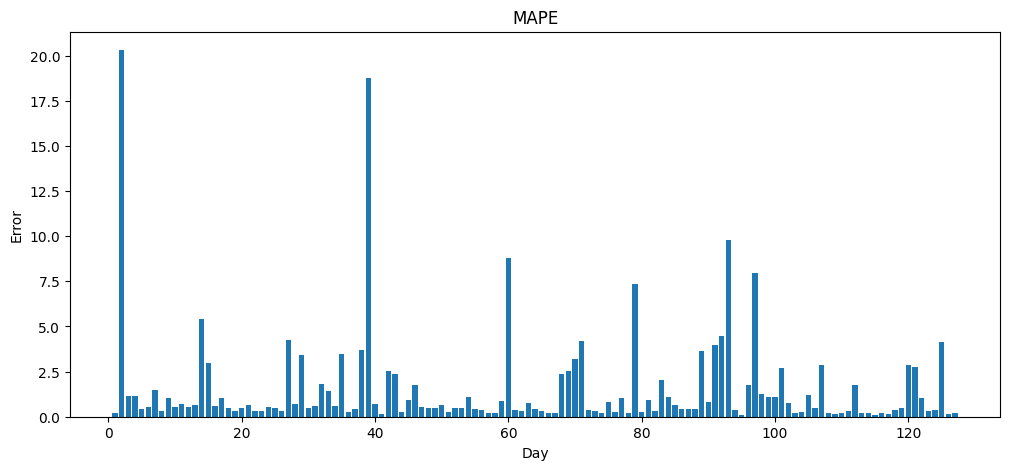

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa1_v2)+1), real_mape_poa1_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Model summary

In [ ]:
model1_POA_Rear_BiLSTM2_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 384, 256)  │    147,456 │ seq-input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 384, 256)  │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 64)        │     73,984 │ dropout_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 96)        │      9,312 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 480)       │     46,560 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 96, 5)     │          0 │ Irr_output[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 844,898 (3.22 MB)

 Trainable params: 281,632 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 563,266 (2.15 MB)

Check the graphs to understand atypical errors

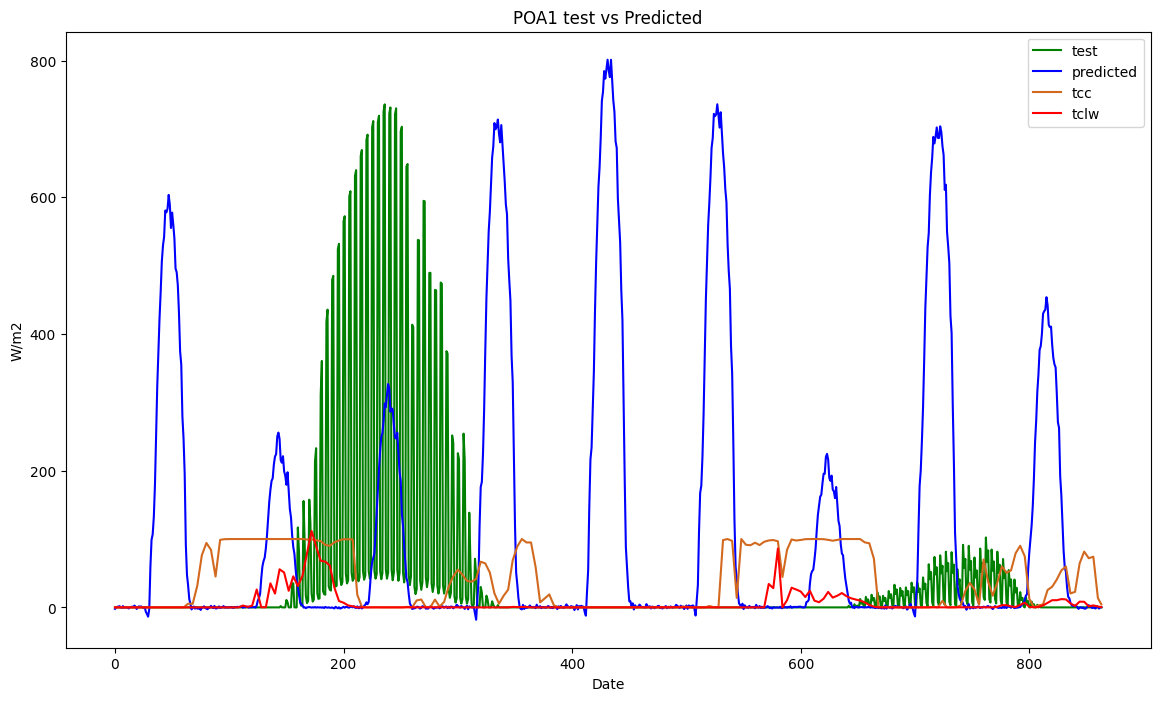

In [ ]:
plt.figure(figsize=(14,8))
st_day=1
end_day=10
dat_clouds=yR_POA_Rear_test.shape[0]*yR_POA_Rear_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA_Rear_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA1_p1_v2[:,:,0].reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()